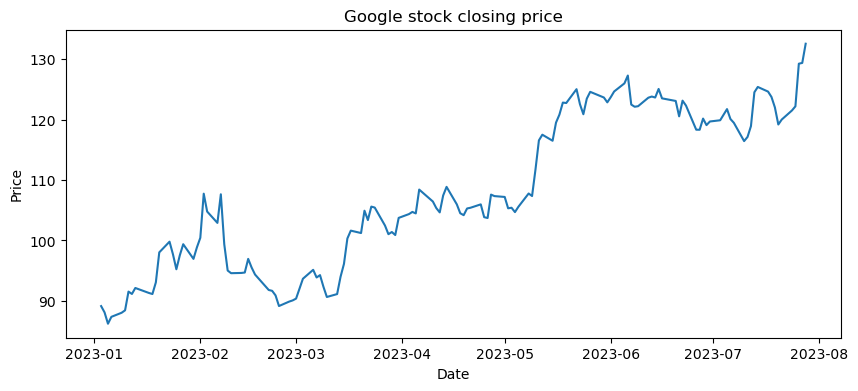

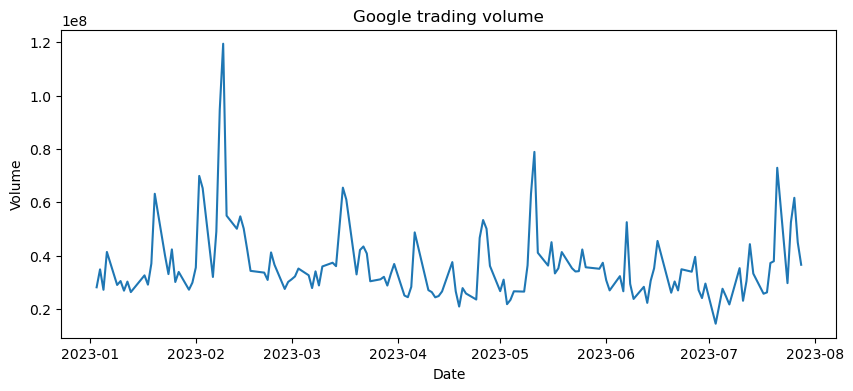

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf
import numpy as np

# indlæs data
df = pd.read_csv("Google_Stock.txt")

# konverter dato
df["Date"] = pd.to_datetime(df["Date"])

# sortér efter dato
df = df.sort_values("Date")

# plot closing price
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Close"])
plt.title("Google stock closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# plot volume
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Volume"])
plt.title("Google trading volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

<Figure size 1000x400 with 0 Axes>

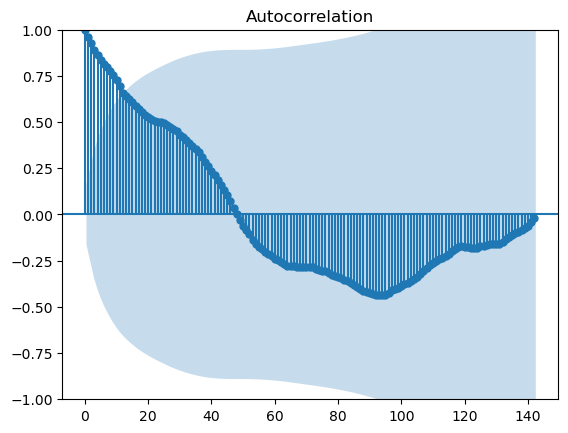

In [2]:
plt.figure(figsize=(10,4))
plot_acf(df["Close"], lags=142)
plt.show()

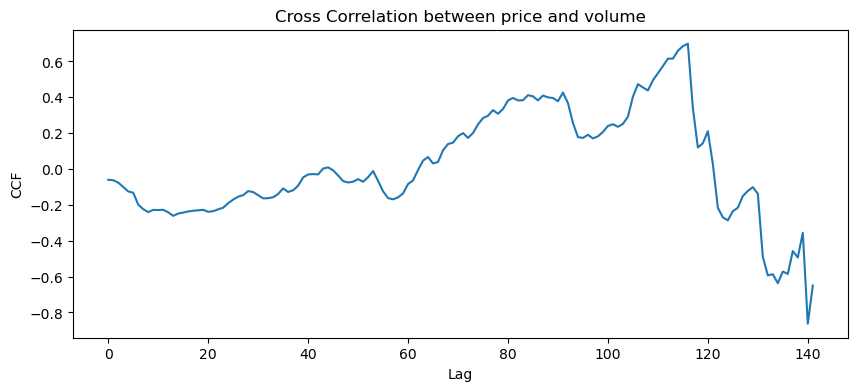

In [3]:
price = df["Close"] - df["Close"].mean()
volume = df["Volume"] - df["Volume"].mean()

ccf_values = ccf(price, volume)

lags = np.arange(len(ccf_values))

plt.figure(figsize=(10,4))
plt.plot(lags[:142], ccf_values[:142])
plt.title("Cross Correlation between price and volume")
plt.xlabel("Lag")
plt.ylabel("CCF")
plt.show()